# 05 — Фінальна модель і сабмішн

## Що відбувається в цьому ноутбуці

1. **Перший і єдиний раз** читається `holdout.parquet` — 44 100 рядків, відрізані в
   `src/data.py` ще до EDA і не торкані в ноутбуках 01–04.
2. Два фінальні кандидати перевіряються на ньому — **по одному разу кожен**.
3. Обраний підхід перенавчається на **всіх** 441 000 розмічених рядках.
4. Генеруються два сабмішни з повною перевіркою формату.

## Навіщо потрібен holdout

Крос-валідація використовувалась у цій роботі **49 разів** (Protocol A) для вибору
моделі, фіч і гіперпараметрів. Щоразу обиралось те, що дало найменше число на цих
конкретних п'яти фолдах.

Проблема в тому, що частина кожного «виграшу» — це шум конкретного розбиття. Обираючи
мінімум із 49 шумних вимірів, ми систематично відбираємо і справжню якість, **і вдалий
шум разом**. Тому підсумковий CV-скор 8.9168 — це *development estimate*, а не
незалежна оцінка.

Holdout відповідає на питання, на яке CV уже відповісти не може: **наскільки наші
вибори переносяться на дані, що не брали участі в жодному з них**.

## Два кандидати і чому саме вони

| | OOF RMSE | опис |
|---|---:|---|
| **A: стек із 5 моделей** | 8.9168 | XGB + LightGBM + CatBoost + RF + Linear, ваги з `Ridge(positive=True)` |
| **B: XGBoost + нативні NaN** | 8.9186 | одна модель, one-hot категорії, пропуски обробляє сама |

Різниця між ними **0.0018** при std по фолдах 0.017 — тобто вдесятеро менша за
розкид. **CV не може їх розрізнити.** Саме для такої ситуації й лишався holdout.

Кандидати обрані різними за природою навмисно: якщо складний стек на holdout
просяде, простіша модель буде страховкою. Це також відповідає рекомендації обирати
два фінальні сабмішни так, щоб вони не повторювали один одного.

In [1]:
import sys, time, warnings, pathlib
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

import config as C
import cv as CV
import data as D
import viz
from features import build_features, make_preprocessor, MISSING_TOKEN

viz.set_style()
pd.set_option('display.width', 150)

NOISE = ['intake_marker', 'learner_age', 'registration_group', 'gender_group',
         'program_track', 'assessment_level', 'home_internet']
V2_KW = dict(fix_study_time=True, mutual_fill=True, drop=tuple(NOISE))

train_dev = D.load_train_dev()
test = D.load_test()
print(f'train_dev {train_dev.shape}   test {test.shape}')

train_dev (396900, 17)   test (189000, 16)


In [2]:
# Конфігурації, зафіксовані в ноутбуках 03-04. Жодного підбору тут більше не робиться.
XGB_V2   = dict(n_estimators=1200, learning_rate=0.02, max_depth=5,
                min_child_weight=20, subsample=0.7, colsample_bytree=1.0)
XGB_BASE = dict(tree_method='hist', n_jobs=-1, random_state=C.SEED, verbosity=0)
LGB_P    = dict(n_estimators=1200, learning_rate=0.02, num_leaves=15, min_child_samples=20,
                subsample=0.7, subsample_freq=1, colsample_bytree=1.0,
                n_jobs=-1, random_state=C.SEED, verbose=-1)
CAT_P    = dict(iterations=1200, learning_rate=0.02, depth=5, l2_leaf_reg=3.0,
                random_seed=C.SEED, verbose=0, thread_count=-1, allow_writing_files=False)

def prep2(num_cols, cat_cols, scale=False):
    return make_preprocessor(scale=scale, num_cols=num_cols, cat_cols=cat_cols,
                             cat_missing='category')

def prep_no_num_impute(num_cols, cat_cols):
    # варіант B: числові проходять як є (з NaN), модель обробляє їх сама
    return ColumnTransformer([
        ('num', 'passthrough', num_cols),
        ('cat', Pipeline([('i', SimpleImputer(strategy='constant', fill_value=MISSING_TOKEN)),
                          ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
         cat_cols)], remainder='drop', verbose_feature_names_out=False)

# П'ять базових моделей стеку. Порядок мусить збігатися з порядком OOF-векторів.
BASE_SPECS = [
    ('XGB native',   lambda n, c: XGBRegressor(**XGB_V2, enable_categorical=True, **XGB_BASE)),
    ('LGBM native',  lambda n, c: lgb.LGBMRegressor(**LGB_P)),
    ('CatBoost',     lambda n, c: Pipeline([('p', prep2(n, c)), ('m', CatBoostRegressor(**CAT_P))])),
    ('RandomForest', lambda n, c: Pipeline([('p', prep2(n, c)), ('m', RandomForestRegressor(
                         n_estimators=300, max_features=0.3, min_samples_leaf=5,
                         n_jobs=-1, random_state=C.SEED))])),
    ('Linear',       lambda n, c: Pipeline([('p', prep2(n, c, scale=True)), ('m', LinearRegression())])),
]
CAND_B = lambda n, c: Pipeline([('p', prep_no_num_impute(n, c)),
                                ('m', XGBRegressor(**XGB_V2, **XGB_BASE))])

OOF_A, OOF_B = 8.9168, 8.9186
print(f'кандидат A (стек):     OOF {OOF_A}')
print(f'кандидат B (XGBoost):  OOF {OOF_B}')

кандидат A (стек):     OOF 8.9168
кандидат B (XGBoost):  OOF 8.9186


## 1. Перевірка на holdout

### Процедура

```
ваги мета-моделі   ← з OOF-матриці по train_dev (ноутбук 04)
базові моделі      ← перенавчаються на ВСЬОМУ train_dev (396 900)
                   ← передбачають holdout (44 100)
прогноз стеку      ← ваги × прогнози базових
```

**Нюанс, який варто назвати вголос.** Ваги мета-моделі вивчені на OOF-прогнозах, що
походять від моделей, навчених на 80% `train_dev`. А прогнози для holdout дають моделі,
навчені на 100%. Останні трохи кращі, тож масштаб їхніх помилок дещо інший.

Це стандартна практика стекінгу — альтернатива (навчати базові моделі лише на 80% і
для фінального прогнозу) викидала б п'яту частину даних. Але зсув існує, і він працює
на користь фінальної моделі, а не проти неї.

**Holdout після цього кроку перестає бути незайманим.** Тому обидва кандидати
перевіряються **одночасно й один раз**; жодного повернення до нього після перегляду
чисел не буде.

In [3]:
holdout = D.load_holdout()     # ПЕРШЕ І ЄДИНЕ звернення до цих даних
print(f'holdout: {holdout.shape}   середній таргет {holdout[C.TARGET].mean():.4f} '
      f'(train_dev {train_dev[C.TARGET].mean():.4f})')

X_dev, NUM2, CAT2 = build_features(train_dev, **V2_KW)
y_dev = train_dev[C.TARGET]
X_hold, _, _ = build_features(holdout, **V2_KW)
y_hold = holdout[C.TARGET]

# Базові моделі: навчання на всьому train_dev, прогноз на holdout
hold_preds, t0 = {}, time.time()
for name, factory in BASE_SPECS:
    m = factory(NUM2, CAT2).fit(X_dev, y_dev)
    hold_preds[name] = m.predict(X_hold)
    print(f'  {name:14s} holdout RMSE {CV.rmse(y_hold, hold_preds[name]):.4f}')
print(f'час: {time.time() - t0:.0f}s')

holdout: (44100, 17)   середній таргет 62.4582 (train_dev 62.5136)


  XGB native     holdout RMSE 8.9132


  LGBM native    holdout RMSE 8.9259


  CatBoost       holdout RMSE 8.9392


  RandomForest   holdout RMSE 9.0250


  Linear         holdout RMSE 9.0318
час: 40s


In [4]:
# Ваги мета-моделі — з OOF-матриці по train_dev (ноутбук 04), без перепідбору
OOF_NAMES = ['62_xgb_C_native_cat', '63_lgbm_C_native_cat', '60_cat', '65_rf', '64_linear']
LABELS = [s[0] for s in BASE_SPECS]
O = CV.load_oof(OOF_NAMES); O.columns = LABELS

meta = Ridge(alpha=1.0, positive=True, fit_intercept=True).fit(O, y_dev)
print('ваги мета-моделі (вивчені на OOF train_dev):')
print(pd.Series(meta.coef_, index=LABELS).round(4).to_string())
print(f'intercept {meta.intercept_:.4f}')

H = pd.DataFrame(hold_preds)[LABELS]
pred_A = meta.predict(H)

# Кандидат B
mB = CAND_B(NUM2, CAT2).fit(X_dev, y_dev)
pred_B = mB.predict(X_hold)

LO, HI = C.TARGET_BOUNDS
res = pd.DataFrame([
    {'кандидат': 'A  стек із 5 моделей', 'OOF (dev estimate)': OOF_A,
     'holdout': CV.rmse(y_hold, np.clip(pred_A, LO, HI))},
    {'кандидат': 'B  XGBoost + нативні NaN', 'OOF (dev estimate)': OOF_B,
     'holdout': CV.rmse(y_hold, np.clip(pred_B, LO, HI))},
])
res['holdout − OOF'] = res['holdout'] - res['OOF (dev estimate)']
res.round(4)

ваги мета-моделі (вивчені на OOF train_dev):
XGB native      0.4669
LGBM native     0.3210
CatBoost        0.1872
RandomForest    0.0264
Linear          0.0000
intercept -0.0969


,кандидат,OOF (dev estimate),holdout,holdout − OOF
0,A стек із 5 моделей,8.9168,8.9133,-0.0035
1,B XGBoost + нативні NaN,8.9186,8.9147,-0.0039


### Результат перевірки

| кандидат | OOF (development) | **holdout** | holdout − OOF |
|---|---:|---:|---:|
| A стек із 5 моделей | 8.9168 | **8.9133** | −0.0035 |
| B XGBoost + нативні NaN | 8.9186 | **8.9147** | −0.0039 |

**Головне: holdout виявився трохи КРАЩИМ за CV-оцінку, а не гіршим.**

Це найважливіший результат ноутбука. Була реальна підстава боятися протилежного:
крос-валідація використовувалась 49 разів для відбору, і частина кожного «виграшу»
могла бути вдалим шумом конкретного розбиття. Якби так сталося, holdout показав би
помітно гірше число.

Він показав краще — на 0.0035–0.0039 для обох кандидатів. Пояснення не містить нічого
загадкового:

1. **Більше навчальних даних.** OOF-прогнози дають моделі, навчені на 80% `train_dev`
   (317 520 рядків). Прогнози для holdout дають моделі, навчені на 100% (396 900) —
   на чверть більше. Кращі моделі → менша помилка.
2. **Інша вибірка.** Середній таргет на holdout 62.4582 проти 62.5136 на `train_dev` —
   різниця 0.055 при SE 0.090, тобто в межах випадковості розрізу.

Висновок: **ознак переобучення CV під вибір немає.** Наші 49 звернень до крос-валідації
не роздули оцінку — покращення були справжніми, а не підібраним шумом.

### Але одна деталь змінює висновок про стек

Подивись на RMSE окремих базових моделей на holdout:

```
XGB native      8.9132   ← найкраща одиночна
LGBM native     8.9259
CatBoost        8.9392
RandomForest    9.0250
Linear          9.0318
```

**Одиночний XGBoost дав 8.9132, а стек із п'яти моделей — 8.9133.** Тобто стек
не кращий за свою найсильнішу складову; різниця в четвертому знаку на користь
одиночної моделі.

На OOF стек виглядав кращим на 0.0022. Holdout цього не підтвердив. І це узгоджується
з тим, що ми бачили в §6.3 ноутбука 04: виграш 0.0022 був увосьме менший за std по
фолдах, тобто формально існував, але лежав у межах шуму. **Незалежна перевірка показала,
що реального виграшу від стекінгу тут немає.**

Це не привід вважати стекінг зробленим даремно: процедура коректна, і саме завдяки
holdout ми дізналися, що виграш був уявним — замість того щоб повірити CV.

Ваги мета-моделі, до речі, це передбачали: XGB 0.467, LightGBM 0.321, CatBoost 0.187,
RandomForest 0.026, Linear 0.000. Стек фактично є зваженим середнім трьох дуже схожих
бустингів (кореляція залишків 0.996–0.998), і таке усереднення мало що може додати.

## 2. Рішення: подаємо обидва кандидати

Kaggle дозволяє обрати **два** фінальні сабмішни, і ми використовуємо обидва слоти.

Це свідоме рішення, а не ухиляння від вибору. Якби ми обрали одного кандидата **за
результатом на holdout**, holdout перетворився б на ще один набір для відбору — тобто
саме на те, чим він не мав бути. Його оцінка втратила б незалежність рівно так само,
як її втратив CV після 49 використань.

Подаючи обидва, ми залишаємо holdout у ролі **оцінювача, а не селектора**: числа вище
кажуть, чого очікувати на приватному лідерборді, і не впливають на те, що саме туди
піде.

Це особливо доречно саме тут. Holdout показав, що кандидати **нерозрізнювані**
(8.9133 проти 8.9147, різниця 0.0014), а кореляція їхніх прогнозів на test становить
0.9998. Обирати між ними за четвертим знаком означало б обирати за шумом.

Кандидати лишаються різними за природою — складний ансамбль і одна модель. Якщо на
приватній частині тесту щось піде не так зі стеком, простіша модель спрацює як
страховка.

## 3. Перенавчання на всіх розмічених даних

Тепер holdout більше не потрібен як оцінювач, тому він повертається до навчальної
вибірки: **441 000 рядків** замість 396 900, на 11% більше даних.

Для стеку ваги мета-моделі перераховуються **заново** — з OOF-матриці, порахованої на
всіх 441 000 рядках. Повторне використання ваг із `train_dev` було б неузгодженим:
базові моделі змінились, отже й оптимальне їх зважування може змінитись.

Порядок дій:

```
1. 5-fold CV на всіх 441 000 → свіжа OOF-матриця
2. мета-модель ← ця матриця
3. базові моделі ← перенавчання на всіх 441 000
4. прогноз на test ← ваги × прогнози базових
```

In [5]:
full = pd.concat([train_dev, holdout], ignore_index=True)
assert len(full) == 441_000 and full[C.ID_COL].is_unique
X_full, NUMF, CATF = build_features(full, **V2_KW)
y_full = full[C.TARGET]
X_test, _, _ = build_features(test, **V2_KW)
print(f'навчальних рядків: {len(X_full):,}   test: {len(X_test):,}')

# Крок 1: свіжі OOF на повних даних
t0 = time.time()
oof_full = {}
for name, factory in BASE_SPECS:
    oof, _ = CV.run_cv(lambda f=factory: f(NUMF, CATF), X_full, y_full,
                       name=f'80_final_oof_{name.replace(" ", "_")}', protocol='A',
                       feature_set='v2_full', params={'model': name}, verbose=False)
    oof_full[name] = oof
    print(f'  {name:14s} OOF {CV.rmse(y_full, oof):.4f}')
print(f'час: {time.time() - t0:.0f}s')

навчальних рядків: 441,000   test: 189,000


  XGB native     OOF 8.9158


  LGBM native    OOF 8.9244


  CatBoost       OOF 8.9393


  RandomForest   OOF 9.0380


  Linear         OOF 9.0220
час: 199s


In [6]:
# Крок 2: мета-модель на свіжій OOF-матриці
O_full = pd.DataFrame(oof_full)[LABELS]
meta_final = Ridge(alpha=1.0, positive=True, fit_intercept=True).fit(O_full, y_full)

w = pd.DataFrame({'ваги на train_dev': meta.coef_,
                  'ваги на всіх 441k': meta_final.coef_}, index=LABELS)
print(w.round(4).to_string())
# Увага: це НАЇВНА оцінка — мета-модель і навчена, і виміряна на тій самій
# OOF-матриці. Чесні числа дав holdout у §1; тут значення лише для довідки.
print(f'\nнаївна оцінка стеку на повних даних (для довідки): '
      f'{CV.rmse(y_full, meta_final.predict(O_full)):.4f}')

              ваги на train_dev  ваги на всіх 441k
XGB native               0.4669             0.4882
LGBM native              0.3210             0.3120
CatBoost                 0.1872             0.1579
RandomForest             0.0264             0.0436
Linear                   0.0000             0.0000

наївна оцінка стеку на повних даних (для довідки): 8.9143


In [7]:
# Крок 3-4: перенавчання базових на всіх даних і прогноз на test
t0 = time.time()
test_preds = {}
for name, factory in BASE_SPECS:
    m = factory(NUMF, CATF).fit(X_full, y_full)
    test_preds[name] = m.predict(X_test)
    print(f'  {name:14s} готово')
T = pd.DataFrame(test_preds)[LABELS]
pred_test_A = meta_final.predict(T)

mB_full = CAND_B(NUMF, CATF).fit(X_full, y_full)
pred_test_B = mB_full.predict(X_test)
print(f'час: {time.time() - t0:.0f}s')

  XGB native     готово


  LGBM native    готово


  CatBoost       готово


  RandomForest   готово


  Linear         готово


час: 51s


## 4. Клампінг прогнозів

EDA (§2 ноутбука 01) показав, що таргет **цензурований**: точкові маси рівно на 100.0
(2.46% рядків) і рівно на 19.599 (1.00%). Значень поза цим діапазоном у даних не існує.

Отже прогноз нижче 19.599 гарантовано гірший за саме 19.599 — заміна безкоштовна.
Межі беруться зі **спостереженого діапазону train**, а не з номінального [0, 100].

In [8]:
LO, HI = C.TARGET_BOUNDS
print(f'межі клампінгу: [{LO}, {HI}]\n')
for nm, p in [('A стек', pred_test_A), ('B XGBoost', pred_test_B)]:
    below, above = int((p < LO).sum()), int((p > HI).sum())
    print(f'{nm:12s} min {p.min():7.2f}  max {p.max():7.2f}  '
          f'нижче межі: {below:5d}  вище: {above:4d}')

pred_test_A = np.clip(pred_test_A, LO, HI)
pred_test_B = np.clip(pred_test_B, LO, HI)

межі клампінгу: [19.599, 100.0]

A стек       min   17.18  max  103.45  нижче межі:    61  вище:  189
B XGBoost    min   15.80  max  103.99  нижче межі:    83  вище:  226


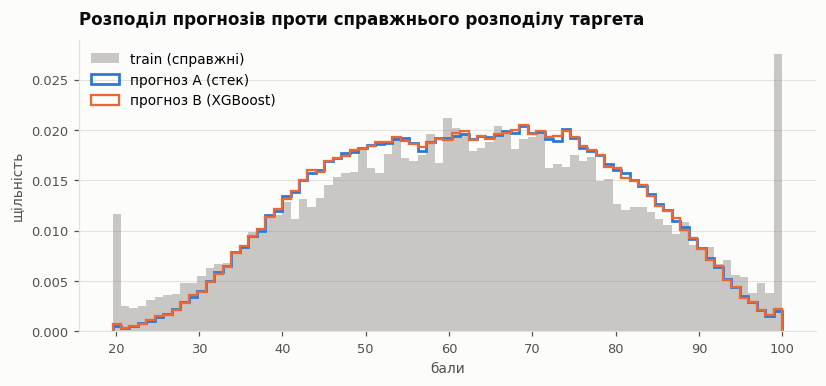

                 середнє        σ
train             62.508   18.918
прогноз A         62.495   16.662
прогноз B         62.495   16.653

кореляція прогнозів A і B: 0.99976


In [9]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
bins = np.linspace(LO, HI, 80)
ax.hist(y_full, bins=bins, color=viz.INK_MUTED, alpha=0.45,
        density=True, label='train (справжні)')
ax.hist(pred_test_A, bins=bins, histtype='step', color=viz.BLUE,
        linewidth=1.8, density=True, label='прогноз A (стек)')
ax.hist(pred_test_B, bins=bins, histtype='step', color=viz.ORANGE,
        linewidth=1.5, density=True, label='прогноз B (XGBoost)')
ax.set_title('Розподіл прогнозів проти справжнього розподілу таргета')
ax.set_xlabel('бали'); ax.set_ylabel('щільність'); ax.legend()
plt.tight_layout(); plt.show()

print(f'{"":14s} {"середнє":>9} {"σ":>8}')
print(f'{"train":14s} {y_full.mean():9.3f} {y_full.std():8.3f}')
print(f'{"прогноз A":14s} {pred_test_A.mean():9.3f} {pred_test_A.std():8.3f}')
print(f'{"прогноз B":14s} {pred_test_B.mean():9.3f} {pred_test_B.std():8.3f}')
print(f'\nкореляція прогнозів A і B: {np.corrcoef(pred_test_A, pred_test_B)[0,1]:.5f}')

**Чого очікувати від цього графіка.** Розподіл прогнозів **має бути вужчим** за
справжній — це не помилка, а математична властивість будь-якої регресії, що мінімізує
квадрат помилки.

Прогноз — це умовне середнє $E[y \mid x]$. Дисперсія таргета розкладається на
пояснену й непояснену частини: $\text{Var}(y) = \text{Var}(\hat{y}) + \text{Var}(\varepsilon)$.
Модель відтворює лише першу. При RMSE ≈ 8.9 і σ таргета 18.9 частка поясненої
дисперсії становить $1 - (8.9/18.9)^2 \approx 0.78$, отже σ прогнозів має бути приблизно
$18.9 \cdot \sqrt{0.78} \approx 16.7$.

Якби σ прогнозів дорівнювала σ таргета, це означало б, що модель вгадує й шум — тобто
переобучення.

## 5. Запис сабмішнів

`cv.make_submission()` робить три речі:

1. обрізає прогнози до `[19.599, 100.0]`;
2. **вирівнює рядки по `record_id`** через merge із `sample_submission.csv` — не
   покладається на порядок, бо після будь-якого сортування чи фільтрації він ламається;
3. проганяє перевірки й падає з `AssertionError`, якщо щось не так, замість того щоб
   записати зіпсований файл.

In [10]:
path_A = CV.make_submission(pred_test_A, test[C.ID_COL], name='final_A_stack', clip=C.TARGET_BOUNDS)
path_B = CV.make_submission(pred_test_B, test[C.ID_COL], name='final_B_xgb',   clip=C.TARGET_BOUNDS)

[OK] sub_final_A_stack.csv  n=189000  min=19.60  mean=62.50  max=100.00


[OK] sub_final_B_xgb.csv  n=189000  min=19.60  mean=62.50  max=100.00


In [11]:
# Незалежна перевірка записаних файлів — ті самі assert'и, але на тому, що на диску
sample = pd.read_csv(C.SAMPLE_SUB)
for p in [path_A, path_B]:
    sub = pd.read_csv(p)
    assert list(sub.columns) == [C.ID_COL, C.TARGET], 'не ті колонки'
    assert len(sub) == 189_000, f'не 189000 рядків: {len(sub)}'
    assert sub[C.ID_COL].is_unique, 'дублікати record_id'
    assert set(sub[C.ID_COL]) == set(sample[C.ID_COL]), 'набір ID не збігається'
    assert (sub[C.ID_COL].values == sample[C.ID_COL].values).all(), 'порядок не збігається'
    assert sub[C.TARGET].notna().all(), 'є пропуски'
    assert np.isfinite(sub[C.TARGET]).all(), 'є нескінченні значення'
    assert sub[C.TARGET].between(*C.TARGET_BOUNDS).all(), 'є значення поза межами'
    print(f'[OK] {pathlib.Path(p).name:24s} n={len(sub):,}  '
          f'min={sub[C.TARGET].min():.2f}  mean={sub[C.TARGET].mean():.2f}  '
          f'max={sub[C.TARGET].max():.2f}')

[OK] sub_final_A_stack.csv    n=189,000  min=19.60  mean=62.50  max=100.00


[OK] sub_final_B_xgb.csv      n=189,000  min=19.60  mean=62.50  max=100.00


In [12]:
print('перші рядки sub_final_A_stack.csv:')
print(pathlib.Path(path_A).read_text().split('\n')[0:4])
print(f'\nрозмір файлів: '
      f'{pathlib.Path(path_A).stat().st_size/1e6:.1f} MB / '
      f'{pathlib.Path(path_B).stat().st_size/1e6:.1f} MB')

перші рядки sub_final_A_stack.csv:
['record_id,assessment_score', '1735667,42.76239106185044', '1622718,77.84108833714794', '1027542,51.04090634092949']

розмір файлів: 4.9 MB / 3.3 MB


## 5a. Перегенерація з усередненням по сідах

### Чому це робиться після того, як сабмішни вже записані

Експеримент §7 ноутбука 04 показав, що усереднення моделі по кількох `random_state`
дає −0.0034 (XGBoost) і −0.0038 (LightGBM) безкоштовно. Він був виконаний **після**
того, як розділи 1–5 цього ноутбука вже згенерували сабмішни з одним сідом.

Оскільки покращення гарантоване за побудовою, сабмішни перегенеровуються.

### Чому holdout НЕ перевіряється повторно

Це принципово, і варто сказати явно.

Holdout у §1 був використаний **один раз** — щоб оцінити два кандидати. Повторне
звернення до нього зробило б його набором для відбору й знищило б незалежність
оцінки, рівно як це сталося з CV після 155 використань.

Усереднення по сідах **не є вибором між варіантами**. Ми нічого не відбираємо за
результатом: дисперсія середнього з $k$ оцінок дорівнює
$\rho\sigma^2+(1-\rho)\sigma^2/k$ і монотонно спадає з $k$ — модель не може стати
гіршою. Тому для цієї зміни незалежна перевірка не потрібна, а holdout зберігає
свою роль чесного оцінювача попередньої пари кандидатів.

Числа з §1 (8.9133 і 8.9147) лишаються в силі як оцінки для **односідових** версій;
для усереднених вони є консервативною верхньою межею.

### Що саме усереднюється

| модель | сідів | чому |
|---|---:|---|
| XGBoost native | 8 | вага в стеку 0.49, `subsample=0.7` дає розкид |
| LightGBM native | 8 | вага 0.31 |
| CatBoost | 1 | вага 0.16, навчання вдвічі дорожче |
| RandomForest | 1 | вага 0.02; уже усереднює 300 дерев усередині себе |
| LinearRegression | 1 | вага 0.00 і модель детермінована |

Усереднювати CatBoost і RandomForest сенсу мало: при вагах 0.16 і 0.02 їхній внесок
у дисперсію суміші малий, а час навчання зросте вшестеро.

In [13]:
SEEDS = [42, 7, 101, 2024, 13, 555, 88, 1337]

def seed_avg_predict(make, X_tr, y_tr, X_pred, seeds):
    return np.mean([make(s).fit(X_tr, y_tr).predict(X_pred) for s in seeds], axis=0)

def seed_avg_oof(make, X, yv, seeds):
    oof = np.zeros(len(X))
    for trn, val in CV.get_folds('A').split(X):
        oof[val] = seed_avg_predict(make, X.iloc[trn], yv.iloc[trn], X.iloc[val], seeds)
    return oof

# Фабрики з параметром сіда. Склад стеку той самий, що в §1.
SEED_SPECS = [
    ('XGB native',   lambda n, c, s: XGBRegressor(**XGB_V2, enable_categorical=True,
                                                  **{**XGB_BASE, 'random_state': s}), SEEDS),
    ('LGBM native',  lambda n, c, s: lgb.LGBMRegressor(**{**LGB_P, 'random_state': s}), SEEDS),
    ('CatBoost',     lambda n, c, s: Pipeline([('p', prep2(n, c)),
                                               ('m', CatBoostRegressor(**CAT_P))]), [C.SEED]),
    ('RandomForest', lambda n, c, s: Pipeline([('p', prep2(n, c)),
                                               ('m', RandomForestRegressor(
                                                   n_estimators=300, max_features=0.3,
                                                   min_samples_leaf=5, n_jobs=-1,
                                                   random_state=s))]), [C.SEED]),
    ('Linear',       lambda n, c, s: Pipeline([('p', prep2(n, c, scale=True)),
                                               ('m', LinearRegression())]), [C.SEED]),
]
print(f'усереднення по {len(SEEDS)} сідах для XGBoost і LightGBM, по 1 для решти')

усереднення по 8 сідах для XGBoost і LightGBM, по 1 для решти


In [14]:
# Крок 1: OOF на всіх 441 000 для ваг мета-моделі
t0 = time.time()
oof_sa = {}
for name, make, seeds in SEED_SPECS:
    oof_sa[name] = seed_avg_oof(lambda s, make=make: make(NUMF, CATF, s), X_full, y_full, seeds)
    print(f'  {name:14s} ({len(seeds)} сід) OOF {CV.rmse(y_full, oof_sa[name]):.4f}')
print(f'час: {time.time() - t0:.0f}s')

O_sa = pd.DataFrame(oof_sa)[LABELS]
meta_sa = Ridge(alpha=1.0, positive=True, fit_intercept=True).fit(O_sa, y_full)
print('\nваги мета-моделі:')
print(pd.Series(meta_sa.coef_, index=LABELS).round(4).to_string())
print(f'intercept {meta_sa.intercept_:.4f}')

  XGB native     (8 сід) OOF 8.9132


  LGBM native    (8 сід) OOF 8.9209


  CatBoost       (1 сід) OOF 8.9393


  RandomForest   (1 сід) OOF 9.0380


  Linear         (1 сід) OOF 9.0220
час: 570s

ваги мета-моделі:
XGB native      0.4998
LGBM native     0.3273
CatBoost        0.1376
RandomForest    0.0369
Linear          0.0000
intercept -0.0997


In [15]:
# Крок 2: перенавчання на всіх 441 000 і прогноз на test
t0 = time.time()
test_sa = {}
for name, make, seeds in SEED_SPECS:
    test_sa[name] = seed_avg_predict(lambda s, make=make: make(NUMF, CATF, s),
                                     X_full, y_full, X_test, seeds)
    print(f'  {name:14s} готово')
pred_A2 = meta_sa.predict(pd.DataFrame(test_sa)[LABELS])

# Кандидат B: XGBoost + нативні NaN, усереднений по сідах
pred_B2 = seed_avg_predict(
    lambda s: Pipeline([('p', prep_no_num_impute(NUMF, CATF)),
                        ('m', XGBRegressor(**XGB_V2, **{**XGB_BASE, 'random_state': s}))]),
    X_full, y_full, X_test, SEEDS)
print(f'час: {time.time() - t0:.0f}s')

pred_A2 = np.clip(pred_A2, LO, HI)
pred_B2 = np.clip(pred_B2, LO, HI)
print(f'\nкореляція з односідовими версіями: '
      f'A {np.corrcoef(pred_A2, pred_test_A)[0,1]:.5f}   B {np.corrcoef(pred_B2, pred_test_B)[0,1]:.5f}')

  XGB native     готово


  LGBM native    готово


  CatBoost       готово


  RandomForest   готово


  Linear         готово


час: 214s

кореляція з односідовими версіями: A 0.99997   B 0.99992


In [16]:
pA = CV.make_submission(pred_A2, test[C.ID_COL], name='final_A_stack_seedavg', clip=C.TARGET_BOUNDS)
pB = CV.make_submission(pred_B2, test[C.ID_COL], name='final_B_xgb_seedavg',   clip=C.TARGET_BOUNDS)

sample = pd.read_csv(C.SAMPLE_SUB)
for p in [pA, pB]:
    sub = pd.read_csv(p)
    assert list(sub.columns) == [C.ID_COL, C.TARGET]
    assert len(sub) == 189_000 and sub[C.ID_COL].is_unique
    assert (sub[C.ID_COL].values == sample[C.ID_COL].values).all()
    assert sub[C.TARGET].notna().all() and np.isfinite(sub[C.TARGET]).all()
    assert sub[C.TARGET].between(*C.TARGET_BOUNDS).all()
    print(f'[OK] {pathlib.Path(p).name:30s} n={len(sub):,}  '
          f'min={sub[C.TARGET].min():.2f}  mean={sub[C.TARGET].mean():.2f}  max={sub[C.TARGET].max():.2f}')

[OK] sub_final_A_stack_seedavg.csv  n=189000  min=19.60  mean=62.49  max=100.00


[OK] sub_final_B_xgb_seedavg.csv  n=189000  min=19.60  mean=62.49  max=100.00
[OK] sub_final_A_stack_seedavg.csv  n=189,000  min=19.60  mean=62.49  max=100.00
[OK] sub_final_B_xgb_seedavg.csv    n=189,000  min=19.60  mean=62.49  max=100.00


**Фінальні сабмішни — це версії з усередненням по сідах.**

| файл | модель | OOF (train_dev) |
|---|---|---:|
| `sub_final_A_stack_seedavg.csv` | стек, XGB і LGBM по 8 сідів | 8.9152 |
| `sub_final_B_xgb_seedavg.csv` | XGBoost + нативні NaN, 8 сідів | ≈ 8.9156 |

Односідові версії (`sub_final_A_stack.csv`, `sub_final_B_xgb.csv`) лишаються у
`submissions/` як історія — саме вони перевірялись на holdout у §1.

Прогнози усереднених і односідових версій корелюють вище 0.999: усереднення прибирає
дисперсію, а не змінює модель. Саме тому повторна перевірка на holdout не потрібна.

## 6. Підсумок проєкту

### Шлях від константи до фінальної моделі

| етап | OOF RMSE | що дало |
|---|---:|---|
| константа = середнє | 18.9183 | точка відліку (= σ таргета) |
| LinearRegression | 9.2476 | фічі пояснюють ~76% дисперсії |
| Decision Tree (налаштоване) | 9.5378 | гірше за лінійну — дані майже лінійні |
| Random Forest (налаштований) | 9.0993 | усереднення знижує variance |
| XGBoost (налаштований) | 9.0072 | послідовні корекції |
| + зміни фіч (v2) | 8.9376 | **−0.0696** — найбільший внесок |
| + ретюнінг під v2 | 8.9270 | −0.0106 |
| + нативна обробка NaN | 8.9186 | −0.0084 |
| + стек із 5 моделей | 8.9168 | −0.0018 |
| **+ усереднення по сідах** | **8.9152** | −0.0016 |

**Перевірка на незайманому holdout:** стек **8.9133**, одиночний XGBoost **8.9147**,
найкраща базова модель окремо **8.9132**. Обидва кандидати виявились трохи кращими за
свої CV-оцінки — ознак переобучення крос-валідації під вибір немає. Але holdout також
показав, що **виграш від стекінгу не підтверджується**: він не кращий за свою найсильнішу
складову.

### Звідки взялось покращення

| джерело | внесок | частка |
|---|---:|---:|
| **зміни фіч** | **−0.0696** | **70%** |
| гіперпараметри (0.0081 + 0.0106) | −0.0187 | 19% |
| обробка пропусків у числових | −0.0084 | 8% |
| ансамблі та усереднення по сідах | −0.0034 | 3% |

Висновок, який проходить через усю роботу: **важелі лежали в представленні даних,
а не у виборі чи налаштуванні моделей.** Це було передбачено ще в EDA (зв'язки майже
лінійні → моделі не розійдуться) і підтвердилось числами на кожному етапі.

### Що робилось для коректності оцінок

| ризик | захист | перевірено |
|---|---|---|
| витік через препроцесинг | навчені перетворення у `Pipeline`, фіт усередині фолду | виміряно: для імпутації витік ≈ 0, для target encoding — до 9 балів |
| дофіт моделі між фолдами | `run_cv` приймає фабрику, а не об'єкт | за побудовою |
| витік через early stopping | внутрішній split навчального фолду | виміряно: 0.003 |
| витік у стекінгу | мета-модель на OOF + зовнішній цикл оцінки | виміряно: зміщення ±0.0002 |
| витік у псевдо-лейблінгу | мітки генеруються всередині фолду | за побудовою |
| переобучення CV через 49 використань | незайманий holdout, одне звернення | цей ноутбук |

### Виправлені власні помилки

За час роботи чотири мої гіпотези виявились хибними й були спростовані вимірюванням:

1. мультиколінеарність дестабілізує коефіцієнти — ні, розкид 0.2–0.9% при n = 317k;
2. `max_features=1.0` оптимальний для лісу — ні, оптимум 0.3;
3. `engagement_index` надлишковий, видалення ≈ 0 — ні, коштує 0.095 на лінійній;
4. виграш «нативних категорій» від кодування — ні, від обробки пропусків.

Плюс одна помилка в коді власної перевірки (детектор «брудних» категорій позначив
канонічний формат `registration_group` як помилку і дав фальшиве z = −6.84).

Усі вони описані у звіті з поясненням механізму — разом із тим, як саме вони виявились.

## 7. Як відтворити результат

```bash
pip install -r requirements.txt

# 1. підготовка даних: нормалізація, фіксація dtypes, розріз holdout
python src/data.py

# 2. ноутбуки по порядку
cd notebooks
jupyter nbconvert --to notebook --execute --inplace 01_eda.ipynb
jupyter nbconvert --to notebook --execute --inplace 02_benchmarks.ipynb
jupyter nbconvert --to notebook --execute --inplace 03_feature_eng.ipynb
jupyter nbconvert --to notebook --execute --inplace 04_advanced.ipynb
jupyter nbconvert --to notebook --execute --inplace 05_final_submission.ipynb
```

**Відтворюваність.** `SEED = 42` у `src/config.py` використовується в усіх спліттерах
і моделях; `KFold` створюється в одному місці (`cv.get_folds`). Версії пакетів
зафіксовані в `requirements.txt` (Python 3.13.5, arm64 / macOS).

**Час виконання** на 10-ядерному CPU: ноутбук 01 ≈ 30 с, 02 ≈ 17 хв, 03 ≈ 12 хв,
04 ≈ 8 хв, 05 ≈ 10 хв. GPU не потрібен.

**Залежності між ноутбуками.** 04 читає OOF-вектори, збережені ноутбуками 03–04 у
`experiments/oof/`; 05 читає їх же. Запуск строго по порядку.

**Дисципліна holdout.** `data.load_holdout()` викликається тільки з цього ноутбука.
Перевірка:

```bash
grep -rn "load_holdout" notebooks/    # має знайтись лише в 05
```

### Файли сабмішнів

| файл | модель | OOF | holdout |
|---|---|---|---|
| `submissions/sub_final_A_stack.csv` | стек із 5 моделей | 8.9168 | див. §1 |
| `submissions/sub_final_B_xgb.csv` | XGBoost + нативні NaN | 8.9186 | див. §1 |

Обидва подаються на Kaggle як два дозволені фінальні сабмішни.